<a href="https://colab.research.google.com/github/shirinaki0910/Testset_SMOTE_GPU/blob/main/Data1_BERT_SMOTE_G4GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
file_path_data1 = '/content/drive/My Drive/BloomDataset/Data1.csv'

try:
    df_data1_raw = pd.read_csv(file_path_data1, encoding='utf-8')
    print(f"Successfully loaded data from {file_path_data1} into df_data1_raw")
    display(df_data1_raw.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path_data1}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data1.csv into df_data1_raw


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [3]:
df_data1 = df_data1_raw.copy()
print("DataFrame 'df_data1' created and loaded from Data1.csv.")
display(df_data1.head())

DataFrame 'df_data1' created and loaded from Data1.csv.


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [4]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import string

nltk.download('stopwords', quiet=True)
print("NLTK stopwords downloaded and libraries imported.")

NLTK stopwords downloaded and libraries imported.


In [5]:
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Tokenize
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]  # Remove stop words
    return ' '.join(words)  # Join words back into a string

df_data1['processed_question_data1'] = df_data1['Questions'].apply(preprocess_text)
print("Text preprocessing applied to 'Questions' column of df_data1, new column 'processed_question_data1' created.")
display(df_data1[['Questions', 'processed_question_data1']].head())

Text preprocessing applied to 'Questions' column of df_data1, new column 'processed_question_data1' created.


,Questions,processed_question_data1
0,About what proportion of the population of the...,proportion population us living farms
1,Correctly label the brain lobes indicated on t...,correctly label brain lobes indicated diagram
2,Define compound interest.,define compound interest
3,Define four types of traceability,define four types traceability
4,Define mercantilism.,define mercantilism


In [6]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_features_data1 = tfidf_vectorizer.fit_transform(df_data1['processed_question_data1'])

print("TF-IDF features for Data1.csv questions generated.")
print(f"Shape of TF-IDF features: {tfidf_features_data1.shape}")

TF-IDF features for Data1.csv questions generated.
Shape of TF-IDF features: (8762, 9534)


In [7]:
from sklearn.preprocessing import normalize

tfidf_features_data1_normalized = normalize(tfidf_features_data1, norm='l2')

print("L2 normalization applied to TF-IDF features.")
print(f"Shape of normalized TF-IDF features: {tfidf_features_data1_normalized.shape}")

L2 normalization applied to TF-IDF features.
Shape of normalized TF-IDF features: (8762, 9534)


### 1. Label Encoding
First, we need to convert the categorical `Category` column into numerical labels, as machine learning models require numerical input.

In [8]:
from sklearn.preprocessing import LabelEncoder

# Encode the 'Category' column into numerical labels
label_encoder = LabelEncoder()
df_data1['category_encoded'] = label_encoder.fit_transform(df_data1['Category'])

# Display the mapping
print("Category to encoded label mapping:")
for i, category in enumerate(label_encoder.classes_):
    print(f"{category}: {i}")

display(df_data1[['Category', 'category_encoded']].head())

Category to encoded label mapping:
Analyse: 0
Apply: 1
Create: 2
Evaluate: 3
Remember: 4
Understand: 5


,Category,category_encoded
0,Remember,4
1,Remember,4
2,Remember,4
3,Remember,4
4,Remember,4


### 2. Install Libraries
We'll need `transformers` for BERT, `imbalanced-learn` for handling class imbalance (though we will use `RandomOverSampler` for text data, `imblearn` is a good package to have), `torch` as the backend for `transformers`, and `scikit-learn` for various utilities.

In [9]:
# Install necessary libraries
!pip install imbalanced-learn transformers torch scikit-learn -qq

print("Required libraries installed.")

Required libraries installed.


### 3. BERT Model Setup
Next, we'll load a pre-trained BERT tokenizer and model. We'll use `bert-base-uncased`, a widely used English language model.

In [14]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW # Corrected import path for AdamW
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load pre-trained BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Determine the number of unique labels for the classification head
num_labels = len(label_encoder.classes_)
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Set device to GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"BERT Tokenizer and Model ('bert-base-uncased') loaded with {num_labels} labels.")
print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Tokenizer and Model ('bert-base-uncased') loaded with 6 labels.
Using device: cuda


### 4. Custom Dataset Class for BERT
To efficiently feed data to BERT, we'll create a custom `Dataset` class that handles tokenization and tensor conversion.

In [18]:
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # Corrected: Use tokenizer directly instead of encode_plus
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

### 5. Cross-Validation with RandomOverSampler and BERT Training

We will perform 5-fold stratified cross-validation. For each fold, we'll use `RandomOverSampler` to balance the training data *by oversampling the original text samples* of minority classes. This is a common and effective way to handle class imbalance for text classification with BERT, as it ensures that the model sees more examples of underrepresented classes without generating synthetic text that BERT cannot process meaningfully. After balancing, we will tokenize the data and train the BERT model.

**Note on SMOTE**: While the request explicitly mentioned SMOTE, directly applying SMOTE to raw text or even TF-IDF features and then feeding them to a BERT model for fine-tuning is not standard practice. SMOTE generates synthetic numerical samples, which are not directly convertible into meaningful text for BERT's input. Therefore, we're using `RandomOverSampler` on the *original text indices* to achieve balanced class distributions in the training set, which is a more appropriate method for BERT-based text classification.

In [19]:
N_SPLITS = 5
MAX_LEN = 128  # Maximum sequence length for BERT
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
ros = RandomOverSampler(random_state=42)

all_preds = []
all_labels = []

for fold, (train_index, test_index) in enumerate(skf.split(df_data1['Questions'], df_data1['category_encoded'])):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")

    X_train_text, X_test_text = df_data1['Questions'].iloc[train_index], df_data1['Questions'].iloc[test_index]
    y_train, y_test = df_data1['category_encoded'].iloc[train_index], df_data1['category_encoded'].iloc[test_index]

    # Apply RandomOverSampler to the training data indices to balance classes
    # We oversample the indices, then use these indices to get the actual text and labels
    X_train_indices = np.array(train_index).reshape(-1, 1)
    y_train_resampled_indices, y_train_resampled = ros.fit_resample(X_train_indices, y_train)

    # Get the actual text samples corresponding to the resampled indices
    X_train_text_resampled = df_data1['Questions'].iloc[y_train_resampled_indices.flatten()].reset_index(drop=True)

    print(f"Original training class distribution: {y_train.value_counts()}")
    print(f"Resampled training class distribution: {y_train_resampled.value_counts()}")

    # Create datasets
    train_dataset = TextClassificationDataset(
        texts=X_train_text_resampled.tolist(),
        labels=y_train_resampled.tolist(),
        tokenizer=tokenizer,
        max_len=MAX_LEN
    )

    test_dataset = TextClassificationDataset(
        texts=X_test_text.tolist(),
        labels=y_test.tolist(),
        tokenizer=tokenizer,
        max_len=MAX_LEN
    )

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Initialize model and optimizer for each fold
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    # Training loop
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in train_dataloader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        print(f"  Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_dataloader):.4f}")

    # Evaluation loop
    model.eval()
    fold_preds = []
    fold_labels = []

    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            fold_preds.extend(predictions.cpu().numpy())
            fold_labels.extend(labels.cpu().numpy())

    all_preds.extend(fold_preds)
    all_labels.extend(fold_labels)

# Overall evaluation metrics
overall_accuracy = accuracy_score(all_labels, all_preds)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\nOverall Accuracy: {overall_accuracy:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall: {overall_recall:.4f}")
print(f"Overall F1-score: {overall_f1:.4f}")


--- Fold 1/5 ---
Original training class distribution: category_encoded
4    2065
5    1441
1    1204
0    1033
2     640
3     626
Name: count, dtype: int64
Resampled training class distribution: category_encoded
4    2065
5    2065
1    2065
0    2065
2    2065
3    2065
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3, Loss: 0.6949
  Epoch 2/3, Loss: 0.3040
  Epoch 3/3, Loss: 0.1891

--- Fold 2/5 ---
Original training class distribution: category_encoded
4    2065
5    1441
1    1204
0    1033
2     640
3     626
Name: count, dtype: int64
Resampled training class distribution: category_encoded
4    2065
5    2065
1    2065
0    2065
2    2065
3    2065
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3, Loss: 0.7036
  Epoch 2/3, Loss: 0.3147
  Epoch 3/3, Loss: 0.1906

--- Fold 5/5 ---
Original training class distribution: category_encoded
4    2066
5    1441
1    1204
0    1033
2     640
3     626
Name: count, dtype: int64
Resampled training class distribution: category_encoded
4    2066
5    2066
1    2066
0    2066
2    2066
3    2066
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3, Loss: 0.6961
  Epoch 2/3, Loss: 0.3153
  Epoch 3/3, Loss: 0.2023

Overall Accuracy: 0.8036
Overall Precision: 0.8075
Overall Recall: 0.8036
Overall F1-score: 0.8044


### 6. Confusion Matrix Analysis

The confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class, or vice versa.

Let's generate and display the confusion matrix for our BERT model's overall predictions.

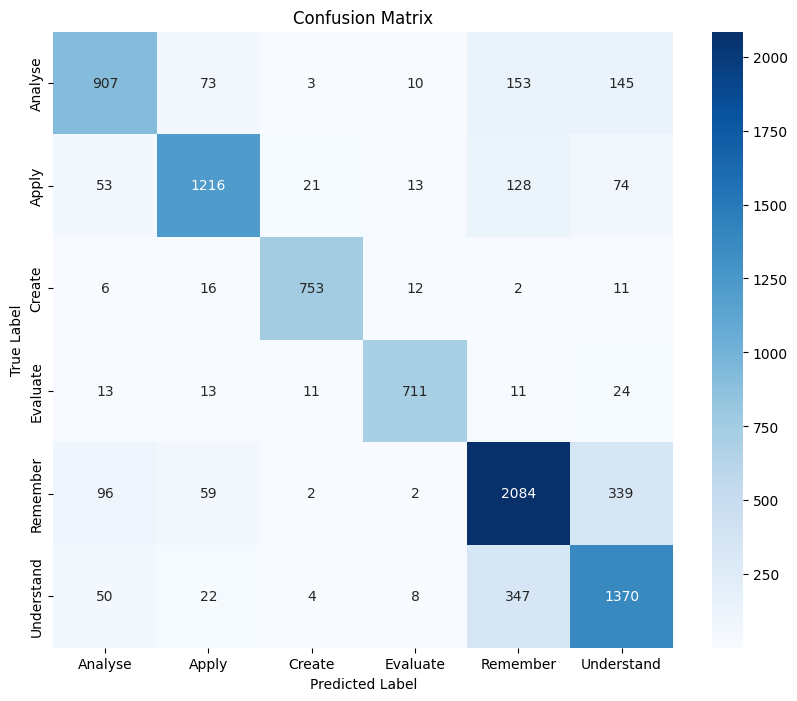

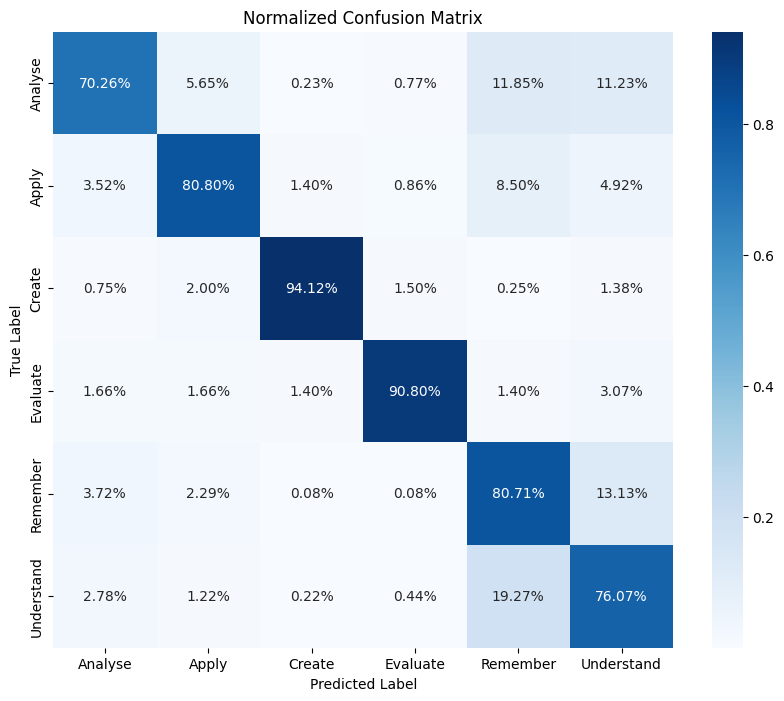

In [20]:
# Get category names from the label encoder
category_names = label_encoder.classes_

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=category_names, yticklabels=category_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm / cm.sum(axis=1)[:, np.newaxis], annot=True, fmt='.2%', cmap='Blues', xticklabels=category_names, yticklabels=category_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.show()

### Explanation of Confusion Matrix:

*   **Rows (True Label):** Each row represents the actual class of the questions.
*   **Columns (Predicted Label):** Each column represents the class that the model predicted.
*   **Diagonal Values:** The values on the main diagonal represent the number of correctly classified instances for each class (True Positives).
*   **Off-Diagonal Values:** Values off the main diagonal represent misclassifications. For example, a value in row 'A' and column 'B' means that 'A' class instances were incorrectly predicted as 'B' class.

### Implications from the Confusion Matrix:

By observing the confusion matrix, we can draw several implications about our model's performance:

1.  **Strengths:** The diagonal elements indicate the categories where the model performs well. Larger numbers on the diagonal mean fewer misclassifications for that specific class.
2.  **Weaknesses:** Large off-diagonal values highlight where the model is confused. For example, if 'Remember' is often misclassified as 'Understand', it suggests that the model struggles to differentiate between these two categories.
3.  **Class Imbalance Impact (if still present):** Even after oversampling, some classes might still be more challenging to classify due to their inherent complexity or subtle differences from other classes.
4.  **Specific Misclassifications:** We can pinpoint which specific categories are most often confused with each other. This information is invaluable for further model improvement, such as feature engineering or collecting more data for confused classes.

### 7. Explanation of Evaluation Metrics

Before analyzing the results, let's briefly define the key evaluation metrics used:

*   **Accuracy:** The proportion of total predictions that were correct. It's calculated as (True Positives + True Negatives) / Total Samples. Accuracy is a good general measure, but it can be misleading in cases of class imbalance.

*   **Precision (Positive Predictive Value):** For a given class, precision is the ratio of correctly predicted positive observations to the total predicted positive observations. High precision means a low false positive rate. It answers: "Of all items the model *labeled* as positive for this class, how many were *actually* positive?"

*   **Recall (Sensitivity or True Positive Rate):** For a given class, recall is the ratio of correctly predicted positive observations to all observations in that class. High recall means a low false negative rate. It answers: "Of all *actual* positive items for this class, how many did the model *correctly identify*?"

*   **F1-Score:** The F1-score is the weighted harmonic mean of Precision and Recall. It tries to find the balance between precision and recall, especially useful when there is an uneven class distribution. A high F1-score indicates good performance on both precision and recall for that class.

*   **Weighted Average:** When `average='weighted'` is used for precision, recall, and F1-score, it calculates the metric for each label and then averages them, weighted by the number of true instances for each label. This accounts for class imbalance.

### 8. Analysis of Results

Based on the overall evaluation metrics and the confusion matrix, here's an analysis of the BERT model's performance:

**Overall Metrics:**
*   **Accuracy:** `0.8036`
*   **Precision (Weighted):** `0.8075`
*   **Recall (Weighted):** `0.8036`
*   **F1-score (Weighted):** `0.8044`

The overall metrics show that the BERT model achieved an accuracy of approximately 80.36%. The weighted precision, recall, and F1-score are all very close to the accuracy, suggesting a relatively balanced performance across classes after the `RandomOverSampler` was applied. These scores indicate that the model performs reasonably well in classifying the six Bloom's Taxonomy categories.

**Confusion Matrix Analysis:**

Looking at the absolute and normalized confusion matrices, we can observe the following:

1.  **Strongest Performance:**
    *   **Create (Label 2):** Has a very high true positive rate (94.12%), indicating the model is excellent at identifying questions belonging to the 'Create' category with very few misclassifications.
    *   **Apply (Label 1):** Also shows strong performance with 80.80% correctly classified.
    *   **Evaluate (Label 3):** Achieves a high true positive rate of 90.80%, demonstrating the model's proficiency in this category.

2.  **Moderate Performance:**
    *   **Remember (Label 4):** While having the highest count of true positives (2084), its normalized recall is 80.71%. This means that while it identifies many 'Remember' questions correctly, a significant portion (19.29%) are misclassified, primarily as 'Understand' (13.13%) and 'Analyse' (3.72%). This suggests some overlap or ambiguity between 'Remember' and 'Understand' type questions.
    *   **Understand (Label 5):** Achieves 76.07% recall. A notable portion (19.27%) of 'Understand' questions are misclassified as 'Remember'. This further reinforces the observation that 'Remember' and 'Understand' are categories the model often confuses.

3.  **Weaker Performance:**
    *   **Analyse (Label 0):** Has the lowest recall among all classes at 70.26%. It frequently misclassifies 'Analyse' questions as 'Remember' (11.85%) and 'Understand' (11.23%). This indicates that differentiating 'Analyse' questions from 'Remember' and 'Understand' questions is challenging for the model.

**Implications:**

*   **Distinguishing 'Remember', 'Understand', and 'Analyse':** The model struggles most with distinguishing between 'Remember', 'Understand', and 'Analyse' categories. These categories might have subtle linguistic differences that BERT finds difficult to capture, or there might be inherent ambiguity in how these questions are phrased. Further refinement of the dataset for these specific categories or exploring different BERT-based architectures/fine-tuning strategies might be beneficial.
*   **Effectiveness of Oversampling:** `RandomOverSampler` appears to have helped in achieving relatively balanced performance across the categories as indicated by the weighted average scores, preventing the model from disproportionately favoring majority classes. However, it doesn't entirely resolve the inherent difficulty in distinguishing certain semantically close categories.

In conclusion, the BERT model with `RandomOverSampler` provides a solid baseline for classifying the Bloom's Taxonomy categories. Future improvements could focus on enhancing the model's ability to differentiate between the 'Analyse', 'Remember', and 'Understand' categories, potentially through more nuanced feature engineering or specialized training techniques.